In [1]:
import scanpy as sc
import pandas as pd

# Set the output directory
sc.settings.figdir = '../../data/figure-outputs/figure-2'

# Set the visual parameters
sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=14,
    dpi_save=200,
    figsize=(6,6),
    format='png'
)

In [2]:
adata = sc.read_h5ad('../../data/figure-inputs/scrna_objects/pretx_cnv_20251010.h5ad')

In [3]:
subject_colors = {
    "FH1001": "#1f77b4",
    "FH1002": "#ff7f0e",
    "FH1003": "#279e68",
    "FH1004": "#d62728",
    "FH1005": "#aa40fc",
    "FH1006": "#8c564b",
    "FH1007": "#e377c2",
    "FH1008": "#b5bd61",
    "FH1009": "#17becf",
    "FH1010": "#aec7e8",
    "FH1011": "#ffbb78",
    "FH1012": "#98df8a",
    "FH1014": "#ff9896",
    "FH1016": "#c5b0d5",
    "FH1017": "#c49c94",
    "FH1018": "#f7b6d2",
    "FH1021": "#dbdb8d",
    "Healthy": "#013801"
}

labels = (
    adata.obs["subject.subjectGuid"]
    .astype(str)
    .apply(lambda x: x if "FH" in x else "Healthy")
)
adata.obs["subject_labels"] = pd.Categorical(labels, categories=subject_colors.keys())
adata.obs["subject_colors"] = (
    adata.obs["subject_labels"].map(subject_colors).astype(str)
)

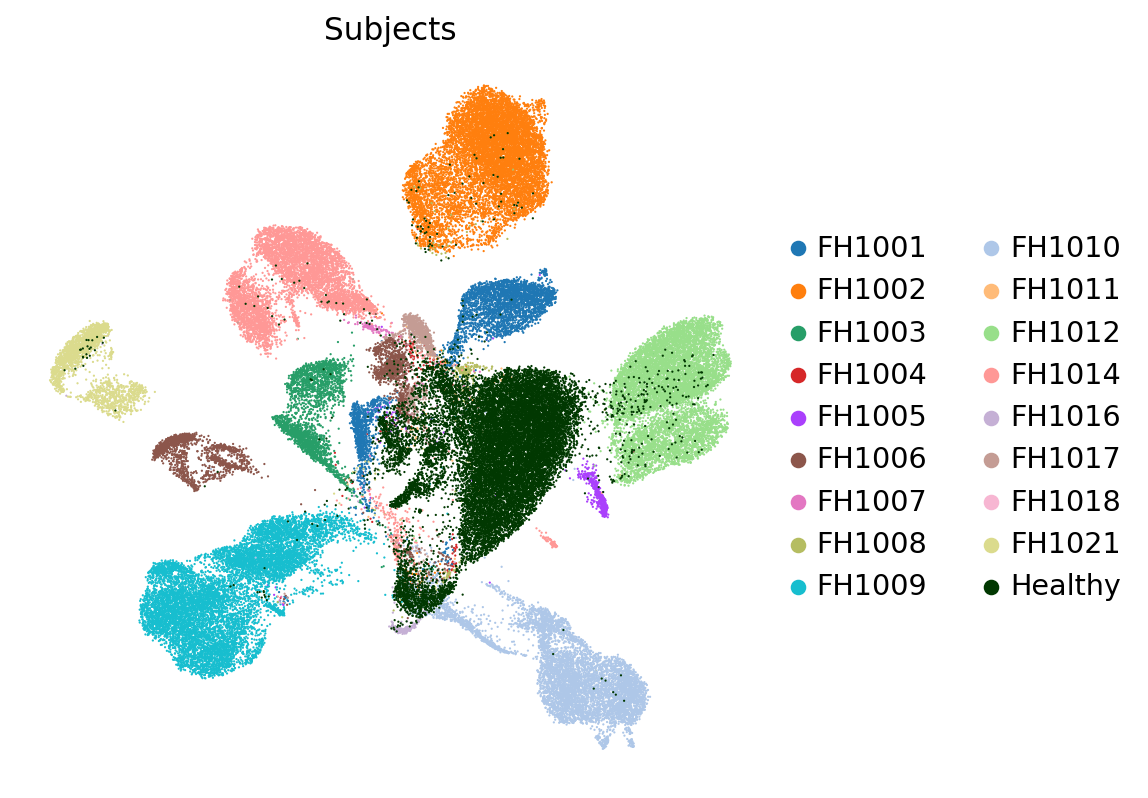

In [4]:
# plot and save umap with new subject labels
sc.pl.umap(
    adata,
    color='subject_labels',
    palette=list(subject_colors.values()),
    title='Subjects',
    size=4,
    save="fig_2b.png"
)